In [8]:
from langchain_text_splitters import CharacterTextSplitter

In [4]:
text = """
Artificial intelligence is transforming technology and shaping the future.
Machine learning algorithms are becoming more sophisticated every day.
Deep learning models can now process vast amounts of data efficiently.

Natural language processing has made significant strides in recent years.
Computer vision systems can now identify objects with remarkable accuracy.
Reinforcement learning is enabling robots to learn complex tasks autonomously.

The impact of AI extends across multiple industries including healthcare, finance, and transport.
Ethical considerations around AI development are becoming increasingly important.
Researchers are working on making AI systems more transparent and explainable.
"""

In [5]:
splitter = CharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=0,
    length_function=len,
    # separator=""
    # separator=" "
    separator="\n\n"
)

chunks = splitter.split_text(text)
chunks

Created a chunk of size 217, which is longer than the specified 100
Created a chunk of size 227, which is longer than the specified 100


['Artificial intelligence is transforming technology and shaping the future.\nMachine learning algorithms are becoming more sophisticated every day.\nDeep learning models can now process vast amounts of data efficiently.',
 'Natural language processing has made significant strides in recent years.\nComputer vision systems can now identify objects with remarkable accuracy.\nReinforcement learning is enabling robots to learn complex tasks autonomously.',
 'The impact of AI extends across multiple industries including healthcare, finance, and transport.\nEthical considerations around AI development are becoming increasingly important.\nResearchers are working on making AI systems more transparent and explainable.']

## splitting documents

In [6]:
from langchain_core.documents import Document

# create documents
docs = [Document(
    page_content=text,
    metadata={"source": "Text on AI"}
)]
docs

[Document(metadata={'source': 'Text on AI'}, page_content='\nArtificial intelligence is transforming technology and shaping the future.\nMachine learning algorithms are becoming more sophisticated every day.\nDeep learning models can now process vast amounts of data efficiently.\n\nNatural language processing has made significant strides in recent years.\nComputer vision systems can now identify objects with remarkable accuracy.\nReinforcement learning is enabling robots to learn complex tasks autonomously.\n\nThe impact of AI extends across multiple industries including healthcare, finance, and transport.\nEthical considerations around AI development are becoming increasingly important.\nResearchers are working on making AI systems more transparent and explainable.\n')]

In [11]:
# create splitter 
splitter = CharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20,
    separator=""
)

chunks = splitter.split_documents(docs)
chunks

[Document(metadata={'source': 'Text on AI'}, page_content='Artificial intelligence is transforming technology and shaping the future.\nMachine learning algorit'),
 Document(metadata={'source': 'Text on AI'}, page_content='ine learning algorithms are becoming more sophisticated every day.\nDeep learning models can now proc'),
 Document(metadata={'source': 'Text on AI'}, page_content='models can now process vast amounts of data efficiently.\n\nNatural language processing has made sign'),
 Document(metadata={'source': 'Text on AI'}, page_content='essing has made significant strides in recent years.\nComputer vision systems can now identify object'),
 Document(metadata={'source': 'Text on AI'}, page_content='now identify objects with remarkable accuracy.\nReinforcement learning is enabling robots to learn c'),
 Document(metadata={'source': 'Text on AI'}, page_content='ng robots to learn complex tasks autonomously.\n\nThe impact of AI extends across multiple industries'),
 Document(metadata

## Text Structure Based Splitting

## What is it?

Recursive chunking is the **most recommended strategy in LangChain**. It attempts to split text hierarchically using a list of separators, starting with larger units (paragraphs) and recursively moving to smaller units (sentences, then words) if chunks are still too large.

Think of it as a smart scissors that tries to cut at natural boundaries - first trying paragraph breaks, then sentence boundaries, and only cutting mid-sentence as a last resort.

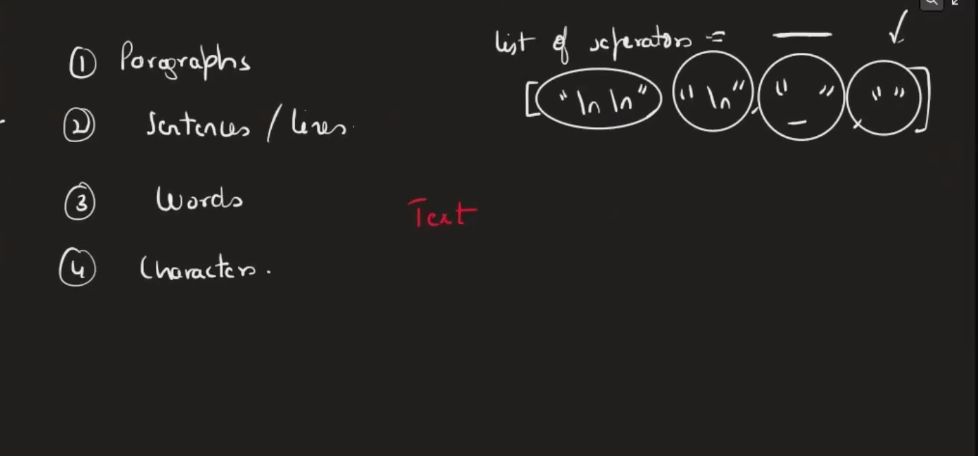

# Recursive Character Text Splitter

Recursive Character Text Splitter document ko **recursively chhote chunks** me split karta hai.

## Main Idea

Ye separators ko **bade se chhote order** me try karta hai:

```text
\n\n  → Paragraph
\n    → Line
" "   → Word
""    → Character
```


![Image](ss1.png)

![Image](ss2.png)

In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text = """Hi how are you

My name is Rahul


I am teaching RAG

We are Learning about RAG"""


In [14]:
splitter = RecursiveCharacterTextSplitter(chunk_size=10, chunk_overlap=0)
splitter.split_text(text)

['Hi how are',
 'you',
 'My name',
 'is Rahul',
 'I am',
 'teaching',
 'RAG',
 'We are',
 'Learning',
 'about RAG']

## Documents

In [15]:
example_text = """Artificial intelligence is transforming technology and shaping the future.

Machine learning algorithms are becoming more sophisticated every day. 
Deep learning models can now process vast amounts of data efficiently.

Natural language processing has made significant strides in recent years.
Transformers architecture revolutionized the field in 2017.
Models like GPT and BERT have set new benchmarks.

Computer vision systems can now identify objects with remarkable accuracy.
Convolutional neural networks excel at image recognition tasks.
Self-driving cars rely heavily on advanced computer vision.

The impact of AI extends across multiple industries including healthcare, finance, and transportation.
Ethical considerations around AI development are becoming increasingly important.
Researchers are working on making AI systems more transparent and explainable."""

In [17]:
from langchain_core.documents import Document

list_of_text = [text, example_text]
docs = [Document(page_content=text) for text in list_of_text]
docs


[Document(metadata={}, page_content='Hi how are you\n\nMy name is Rahul\n\n\nI am teaching RAG\n\nWe are Learning about RAG'),
 Document(metadata={}, page_content='Artificial intelligence is transforming technology and shaping the future.\n\nMachine learning algorithms are becoming more sophisticated every day. \nDeep learning models can now process vast amounts of data efficiently.\n\nNatural language processing has made significant strides in recent years.\nTransformers architecture revolutionized the field in 2017.\nModels like GPT and BERT have set new benchmarks.\n\nComputer vision systems can now identify objects with remarkable accuracy.\nConvolutional neural networks excel at image recognition tasks.\nSelf-driving cars rely heavily on advanced computer vision.\n\nThe impact of AI extends across multiple industries including healthcare, finance, and transportation.\nEthical considerations around AI development are becoming increasingly important.\nResearchers are working on maki

In [19]:
# split the documents
chunk_docs = splitter.split_documents(docs)
chunk_docs

[Document(metadata={}, page_content='Hi how are'),
 Document(metadata={}, page_content='you'),
 Document(metadata={}, page_content='My name'),
 Document(metadata={}, page_content='is Rahul'),
 Document(metadata={}, page_content='I am'),
 Document(metadata={}, page_content='teaching'),
 Document(metadata={}, page_content='RAG'),
 Document(metadata={}, page_content='We are'),
 Document(metadata={}, page_content='Learning'),
 Document(metadata={}, page_content='about RAG'),
 Document(metadata={}, page_content='Artificial'),
 Document(metadata={}, page_content='intellige'),
 Document(metadata={}, page_content='nce'),
 Document(metadata={}, page_content='is'),
 Document(metadata={}, page_content='transform'),
 Document(metadata={}, page_content='ing'),
 Document(metadata={}, page_content='technolog'),
 Document(metadata={}, page_content='y'),
 Document(metadata={}, page_content='and'),
 Document(metadata={}, page_content='shaping'),
 Document(metadata={}, page_content='the'),
 Document(meta

![Image](ss3.png)